# Customer Churn Prediction — SVM vs Decision Tree

## Objective

In this project, we want to predict whether a customer will churn
(leave the company) based on:

- Monthly Charges
- Tenure in Months
- Contract Type
- Number of Support Calls

We will train and compare two classification algorithms:

1. Support Vector Machine (SVM)
2. Decision Tree

We will evaluate them using:

- Accuracy
- Precision
- Recall
- ROC-AUC

Finally, we will use both models to predict the churn probability
of a new customer.

1. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

2. LOAD DATASET

In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()

if (PROJECT_ROOT / "data" / "customer_churn.csv").exists():
    data_path = PROJECT_ROOT / "data" / "customer_churn.csv"
else:
    data_path = Path("customer_churn_tree_svm.csv")

df = pd.read_csv(data_path)

df.head()

,monthly_charges,tenure_months,contract_type,support_calls,churn
0,51.18,15,2,5,0
1,71.09,42,1,2,0
2,33.36,4,0,0,0
3,33.87,51,0,5,0
4,21.10,34,0,5,0


3. UNDERSTAND THE DATASET

In [59]:
print(df.shape)

(150, 5)


In [60]:
print(df.columns.tolist())

['monthly_charges', 'tenure_months', 'contract_type', 'support_calls', 'churn']


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   monthly_charges  150 non-null    float64
 1   tenure_months    150 non-null    int64  
 2   contract_type    150 non-null    int64  
 3   support_calls    150 non-null    int64  
 4   churn            150 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.0 KB


**4. CHECK MISSING VALUES**
The model does not know what `NaN` represents

In [62]:
missing_values = df.isnull().sum()
print(missing_values)

monthly_charges    0
tenure_months      0
contract_type      0
support_calls      0
churn              0
dtype: int64


5. CHECK DUPLICATES

In [63]:
print(df.duplicated().sum())

0


6. DESCRIPTIVE STATISTICS

In [64]:
df.describe()

,monthly_charges,tenure_months,contract_type,support_calls,churn
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,56.650467,28.153333,0.966667,5.546667,0.053333
std,21.928381,17.650118,0.814439,3.517142,0.225450
min,20.450000,1.000000,0.000000,0.000000,0.000000
25%,37.005000,13.000000,0.000000,3.000000,0.000000
50%,56.865000,28.000000,1.000000,5.000000,0.000000
75%,73.805000,44.750000,2.000000,8.750000,0.000000
max,99.270000,59.000000,2.000000,11.000000,1.000000


7. MEAN

In [65]:
print("Mean monthly charges:",
      df["monthly_charges"].mean())

print("Mean tenure:",
      df["tenure_months"].mean())

print("Mean support calls:",
      df["support_calls"].mean())

Mean monthly charges: 56.65046666666667
Mean tenure: 28.153333333333332
Mean support calls: 5.546666666666667


8. MEDIAN

In [66]:
print("Median monthly charges:",
      df["monthly_charges"].median())

print("Median tenure:",
      df["tenure_months"].median())

print("Median support calls:",
      df["support_calls"].median())

Median monthly charges: 56.865
Median tenure: 28.0
Median support calls: 5.0


9. VARIANCE AND STANDARD DEVIATION

In [67]:
print(
    "Monthly Charges Variance:",
    df["monthly_charges"].var()
)

print(
    "Monthly Charges Standard Deviation:",
    df["monthly_charges"].std()
)

Monthly Charges Variance: 480.8538877002236
Monthly Charges Standard Deviation: 21.92838087274625


10. PERCENTILES

In [68]:
print("25th percentile:")
print(df[
    [
        "monthly_charges",
        "tenure_months",
        "support_calls"
    ]
].quantile(0.25))

print("\nMedian:")
print(df[
    [
        "monthly_charges",
        "tenure_months",
        "support_calls"
    ]
].quantile(0.50))

print("\n75th percentile:")
print(df[
    [
        "monthly_charges",
        "tenure_months",
        "support_calls"
    ]
].quantile(0.75))

25th percentile:
monthly_charges    37.005
tenure_months      13.000
support_calls       3.000
Name: 0.25, dtype: float64

Median:
monthly_charges    56.865
tenure_months      28.000
support_calls       5.000
Name: 0.5, dtype: float64

75th percentile:
monthly_charges    73.805
tenure_months      44.750
support_calls       8.750
Name: 0.75, dtype: float64


11. UNDERSTAND THE TARGET

In [69]:
df["churn"].value_counts()

,count
churn,
0,142
1,8


In [70]:
df["churn"].value_counts(normalize=True) * 100

,proportion
churn,
0,94.666667
1,5.333333


12. PROBABILITY OF CHURN

In [71]:
probability_of_churn = df["churn"].mean()

print("Probability of churn:",
      probability_of_churn)

print(
    "Percentage of customers who churn:",
    probability_of_churn * 100,
    "%"
)

Probability of churn: 0.05333333333333334
Percentage of customers who churn: 5.333333333333334 %


13. CONDITIONAL PROBABILITY

In [72]:
df.groupby("contract_type")["churn"].mean()

,churn
contract_type,
0,0.153846
1,0.000000
2,0.000000


14. CONDITIONAL PROBABILITY — SUPPORT CALLS

In [73]:
df.groupby("support_calls")["churn"].mean()

,churn
support_calls,
0,0.000000
1,0.000000
2,0.000000
3,0.090909
4,0.000000
5,0.000000
6,0.000000
7,0.142857
8,0.066667


15. HISTOGRAM — MONTHLY CHARGES

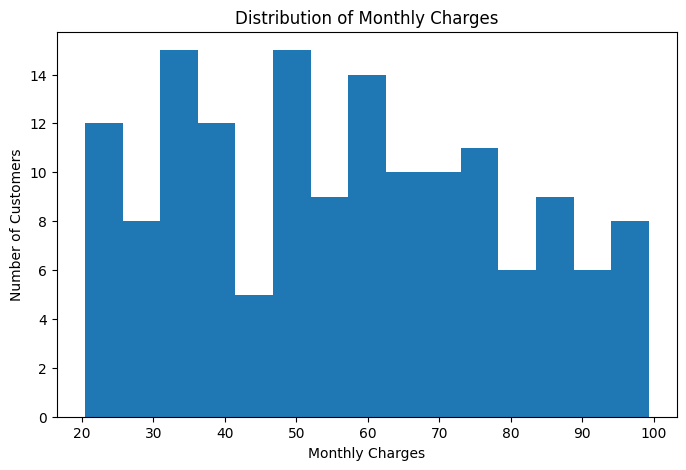

In [74]:
plt.figure(figsize=(8, 5))

plt.hist(df["monthly_charges"], bins=15)

plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")

plt.show()

16. TENURE DISTRIBUTION

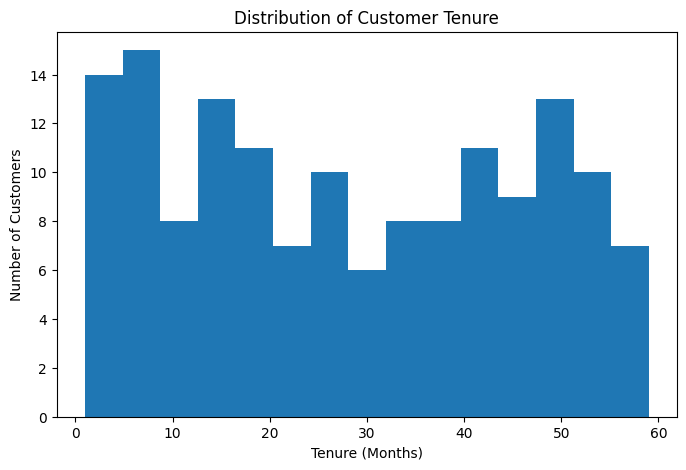

In [75]:
plt.figure(figsize=(8, 5))

plt.hist(df["tenure_months"], bins=15)

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")

plt.show()

17. SUPPORT CALL DISTRIBUTION

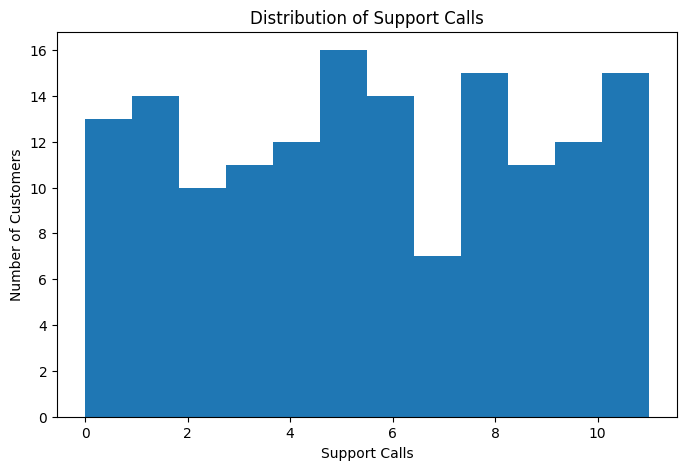

In [76]:
plt.figure(figsize=(8, 5))

plt.hist(df["support_calls"], bins=12)

plt.xlabel("Support Calls")
plt.ylabel("Number of Customers")
plt.title("Distribution of Support Calls")

plt.show()

18. BOXPLOT

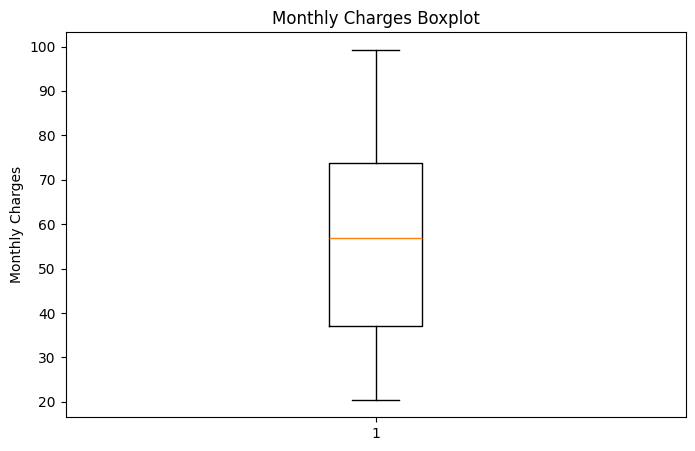

In [77]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["monthly_charges"])

plt.ylabel("Monthly Charges")
plt.title("Monthly Charges Boxplot")

plt.show()

19. CORRELATION

In [78]:
correlation_matrix = df[
    [
        "monthly_charges",
        "tenure_months",
        "contract_type",
        "support_calls",
        "churn"
    ]
].corr()

correlation_matrix

,monthly_charges,tenure_months,contract_type,support_calls,churn
monthly_charges,1.000000,0.130729,0.094580,0.062152,0.168291
tenure_months,0.130729,1.000000,0.003159,0.018425,-0.265181
contract_type,0.094580,0.003159,1.000000,-0.063885,-0.282665
support_calls,0.062152,0.018425,-0.063885,1.000000,0.191511
churn,0.168291,-0.265181,-0.282665,0.191511,1.000000


20. NUMPY REPRESENTATION

In [79]:
features = [
    "monthly_charges",
    "tenure_months",
    "contract_type",
    "support_calls"
]

X = df[features]
y = df["churn"]

X_numpy = X.to_numpy()
y_numpy = y.to_numpy()

print("X shape:", X_numpy.shape)
print("y shape:", y_numpy.shape)

X shape: (150, 4)
y shape: (150,)


21. FEATURE ENGINEERING

In [80]:
df["charge_per_tenure"] = (
    df["monthly_charges"] /
    df["tenure_months"]
)

df[
    [
        "monthly_charges",
        "tenure_months",
        "charge_per_tenure"
    ]
].head()

,monthly_charges,tenure_months,charge_per_tenure
0,51.18,15,3.412000
1,71.09,42,1.692619
2,33.36,4,8.340000
3,33.87,51,0.664118
4,21.10,34,0.620588


22. PREPARE FINAL FEATURES

In [81]:
features = [
    "monthly_charges",
    "tenure_months",
    "contract_type",
    "support_calls"
]

X = df[features]
y = df["churn"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   monthly_charges  tenure_months  contract_type  support_calls
0            51.18             15              2              5
1            71.09             42              1              2
2            33.36              4              0              0
3            33.87             51              0              5
4            21.10             34              0              5

Target:
0    0
1    0
2    0
3    0
4    0
Name: churn, dtype: int64


23. TRAIN-TEST SPLIT

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [83]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 120
Testing samples: 30

Training target distribution:
churn
0    114
1      6
Name: count, dtype: int64

Testing target distribution:
churn
0    28
1     2
Name: count, dtype: int64


24. FEATURE SCALING

In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


25. TRAIN SVM

In [85]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

SVC(probability=True, random_state=42)

26. SVM PREDICTIONS

In [86]:
svm_predictions = svm_model.predict(X_test_scaled)

svm_probabilities = svm_model.predict_proba(
    X_test_scaled
)[:, 1]

27. TRAIN DECISION TREE

In [87]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=4, min_samples_leaf=3,
                       random_state=42)

28. DECISION TREE PREDICTIONS

In [88]:
dt_predictions = dt_model.predict(X_test)

dt_probabilities = dt_model.predict_proba(
    X_test
)[:, 1]

29. MODEL EVALUATION — WHY MULTIPLE METRICS?

A classification model should not be judged using only one metric.

We will calculate:

1. Accuracy
2. Precision
3. Recall
4. ROC-AUC


cauz Customer churn is an imbalanced classification problem.

30. ACCURACY


With an imbalanced dataset, accuracy can be misleading.

In [89]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

print("SVM Accuracy:", svm_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)

SVM Accuracy: 1.0
Decision Tree Accuracy: 1.0


31. PRECISION

Among the customers the model predicted would churn,how many actually churned?

In [90]:
svm_precision = precision_score(
    y_test,
    svm_predictions,
    zero_division=0
)

dt_precision = precision_score(
    y_test,
    dt_predictions,
    zero_division=0
)

print("SVM Precision:", svm_precision)
print("Decision Tree Precision:", dt_precision)

SVM Precision: 1.0
Decision Tree Precision: 1.0


32. RECALL


Among all customers who actually churned,how many did the model successfully identify?

In [91]:
svm_recall = recall_score(
    y_test,
    svm_predictions,
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    dt_predictions,
    zero_division=0
)

print("SVM Recall:", svm_recall)
print("Decision Tree Recall:", dt_recall)

SVM Recall: 1.0
Decision Tree Recall: 1.0


33. ROC-AUC

ROC = Receiver Operating Characteristic.
It examines the model's ability to distinguish between the
positive and negative classes across different classification
thresholds


AUC means:

Area Under the ROC Curve

AUC measures the model's ability to rank positive examples
above negative examples

In [92]:
svm_roc_auc = roc_auc_score(
    y_test,
    svm_probabilities
)

dt_roc_auc = roc_auc_score(
    y_test,
    dt_probabilities
)

print("SVM ROC-AUC:", svm_roc_auc)
print("Decision Tree ROC-AUC:", dt_roc_auc)

SVM ROC-AUC: 1.0
Decision Tree ROC-AUC: 1.0


34. CONFUSION MATRIX

In [93]:
print("SVM Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        svm_predictions
    )
)

SVM Confusion Matrix
[[28  0]
 [ 0  2]]


In [94]:
print("Decision Tree Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        dt_predictions
    )
)

Decision Tree Confusion Matrix
[[28  0]
 [ 0  2]]


35. VISUAL CONFUSION MATRICES

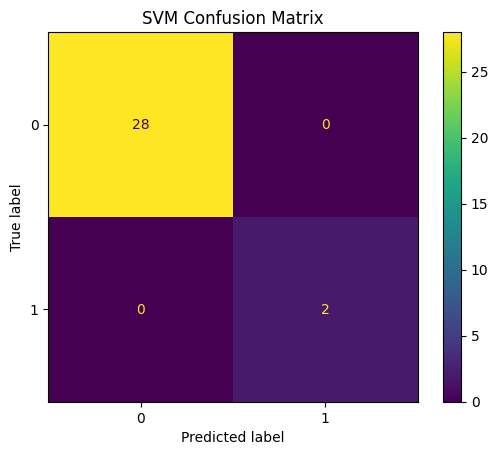

In [95]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_predictions
)

plt.title("SVM Confusion Matrix")

plt.show()

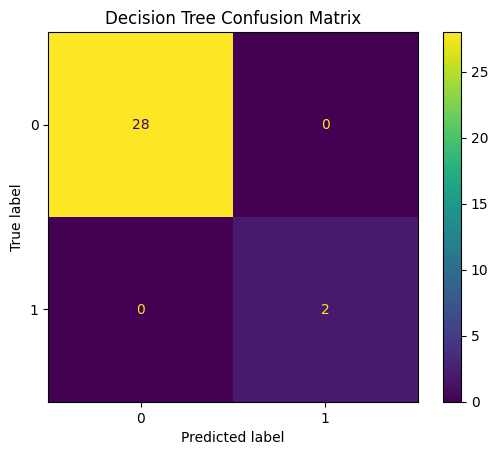

In [96]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_predictions
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

36. COMPLETE CLASSIFICATION REPORT

The classification report combines several important
classification metrics into one output.

We use it to examine the performance separately for:

- No Churn
- Churn

This is particularly useful because our classes are imbalanced.

In [97]:
print("========== SVM ==========")

print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

========== SVM ==========
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00        28
       Churn       1.00      1.00      1.00         2

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [98]:
print("========== SVM ==========")

print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

========== SVM ==========
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00        28
       Churn       1.00      1.00      1.00         2

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



37. VISUALIZE THE DECISION TREE

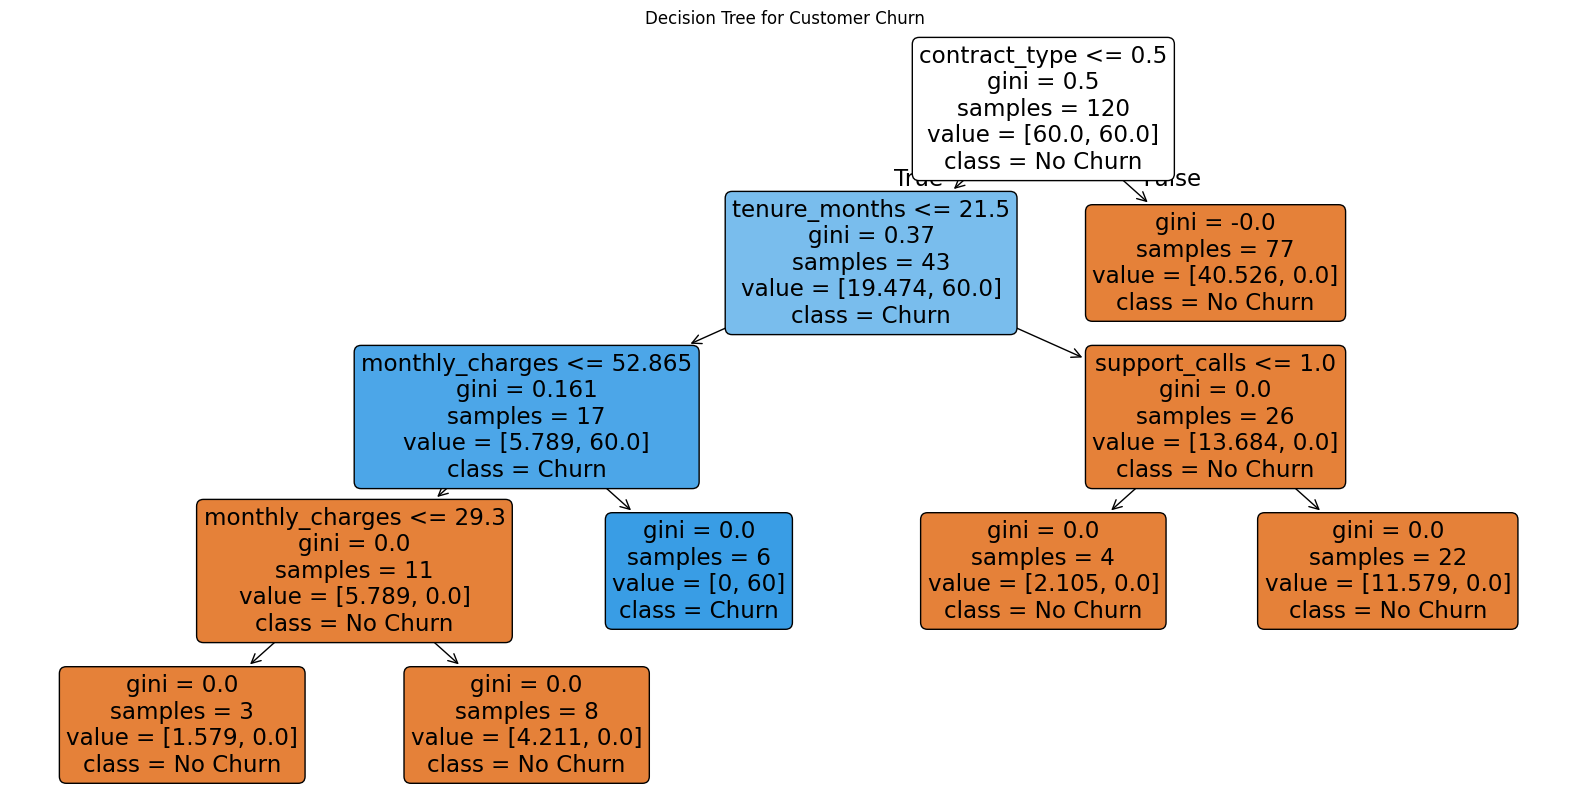

In [99]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=features,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Customer Churn")

plt.show()

38. FEATURE IMPORTANCE

Decision Trees can estimate how much each feature contributed
to reducing impurity across the tree.

This gives us a feature importance value.

## Important distinction

This is NOT feature engineering.

We are not creating features.

We are performing:

**Model Interpretation / Feature Importance Analysis**

Also remember:

Feature importance does not automatically mean
"this feature causes churn."

It tells us how useful the feature was to this particular tree
during its learned splits.

In [100]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": dt_model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,contract_type,5.099338e-01
1,tenure_months,3.140662e-01
0,monthly_charges,1.760000e-01
3,support_calls,1.772461e-16


39. MODEL COMPARISON



In [101]:
comparison = pd.DataFrame({
    "Model": [
        "SVM",
        "Decision Tree"
    ],

    "Accuracy": [
        svm_accuracy,
        dt_accuracy
    ],

    "Precision": [
        svm_precision,
        dt_precision
    ],

    "Recall": [
        svm_recall,
        dt_recall
    ],

    "ROC-AUC": [
        svm_roc_auc,
        dt_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,ROC-AUC
0,SVM,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0


40. ROC CURVE

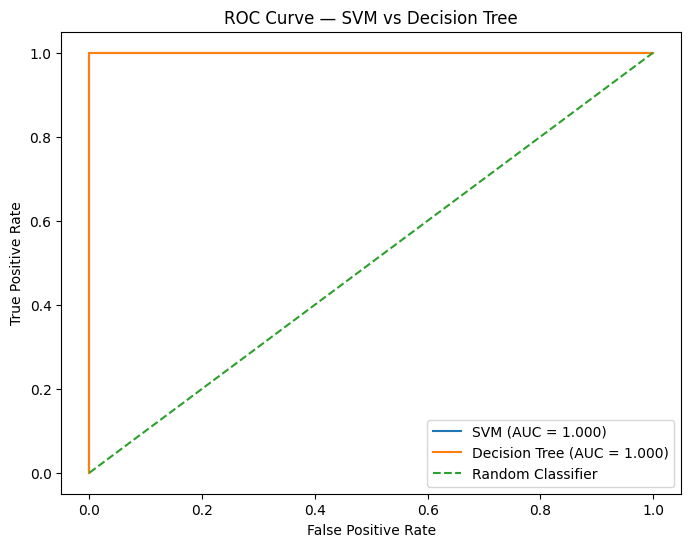

In [102]:
svm_fpr, svm_tpr, _ = roc_curve(
    y_test,
    svm_probabilities
)

dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f"SVM (AUC = {svm_roc_auc:.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — SVM vs Decision Tree")

plt.legend()

plt.show()

41. NEW CUSTOMER

Customer information:

    Monthly Charges = 55
    Tenure          = 24 months
    Contract Type   = 2
    Support Calls   = 1

In [103]:
new_customer = pd.DataFrame({
    "monthly_charges": [55],
    "tenure_months": [24],
    "contract_type": [2],
    "support_calls": [1]
})

new_customer

,monthly_charges,tenure_months,contract_type,support_calls
0,55,24,2,1


42. SVM NEW CUSTOMER



In [104]:
new_customer_scaled = scaler.transform(
    new_customer
)

In [105]:
svm_new_prediction = svm_model.predict(
    new_customer_scaled
)

svm_new_probability = svm_model.predict_proba(
    new_customer_scaled
)[:, 1]

In [106]:
print(
    "SVM Prediction:",
    "Churn" if svm_new_prediction[0] == 1
    else "No Churn"
)

print(
    "SVM Probability of Churn:",
    svm_new_probability[0]
)

SVM Prediction: No Churn
SVM Probability of Churn: 0.024043680256080238


43. DECISION TREE NEW CUSTOMER

In [107]:
dt_new_prediction = dt_model.predict(
    new_customer
)

dt_new_probability = dt_model.predict_proba(
    new_customer
)[:, 1]

In [108]:
print(
    "Decision Tree Prediction:",
    "Churn" if dt_new_prediction[0] == 1
    else "No Churn"
)

print(
    "Decision Tree Probability of Churn:",
    dt_new_probability[0]
)

Decision Tree Prediction: No Churn
Decision Tree Probability of Churn: 0.0


44. FINAL PREDICTION TABLE

In [109]:
prediction_comparison = pd.DataFrame({
    "Model": [
        "SVM",
        "Decision Tree"
    ],

    "Prediction": [
        "Churn" if svm_new_prediction[0] == 1
        else "No Churn",

        "Churn" if dt_new_prediction[0] == 1
        else "No Churn"
    ],

    "Churn Probability": [
        svm_new_probability[0],
        dt_new_probability[0]
    ]
})

prediction_comparison

,Model,Prediction,Churn Probability
0,SVM,No Churn,0.024044
1,Decision Tree,No Churn,0.000000


45. FINAL CONCLUSION

This dataset contains very few churn cases compared with non-churn cases.

Therefore, accuracy can give a misleading impression of model quality.

Recall is particularly important because it measures how many
actual churners were successfully identified.

However, because the dataset is small, the exact metrics from
one train-test split can change substantially depending on which
customers happen to be placed in the test set.

For a production-quality evaluation, we would use
stratified cross-validation and evaluate the model over
multiple folds rather than relying on one split.